# Module 4 — RAG Pipeline

Retrieval-Augmented Generation pipeline for mental health support.

## Approach
- Group duplicate questions and store all counselor responses per question
- Embed the question (context) for semantic search
- Store all responses as metadata in Qdrant
- Experiment with multiple retrieval strategies and compare
- Generate empathetic responses using gpt-oss-120b via Groq

## Dataset
Amod/mental_health_counseling_conversations

## Stack
- Embeddings: sentence-transformers (all-MiniLM-L6-v2)
- Vector DB: Qdrant Cloud
- LLM: Groq API (openai/gpt-oss-120b)

**Before running this notebook, make sure you have installed dependencies:**
pip install -r requirements.txt

# Imports and Checking Environment

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datasets import load_dataset
import re
from collections import Counter

load_dotenv() 

# Verify everything loaded — if any print None, check your .env file
print("GROQ key loaded:   ", "yes" if os.getenv("GROQ_API_KEY") else "NO — CHECK .env")
print("Qdrant URL loaded: ", "yes" if os.getenv("QDRANT_URL") else "NO — CHECK .env")
print("Qdrant key loaded: ", "yes" if os.getenv("QDRANT_API_KEY") else "NO — CHECK .env")

e:\NLP\Mental-Health-RAG-Chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GROQ key loaded:    yes
Qdrant URL loaded:  yes
Qdrant key loaded:  yes


# Load and Explore the Dataset

#### EDA
- Total size and structure
- How many unique questions exist
- How many counselor responses per question
- Text length distribution
- Whether age or gender signals exist in the data

In [2]:
dataset = load_dataset("Amod/mental_health_counseling_conversations")
df_raw = pd.DataFrame(dataset['train'])

print(f"Total rows    : {len(df_raw)}")
print(f"Columns       : {df_raw.columns.tolist()}")
print(f"Null contexts : {df_raw['Context'].isna().sum()}")
print(f"Null responses: {df_raw['Response'].isna().sum()}")
print(f"\nSample row:")
print(f"CONTEXT:\n{df_raw['Context'].iloc[0][:300]}...")
print(f"\nRESPONSE:\n{df_raw['Response'].iloc[0][:300]}...")

Total rows    : 3512
Columns       : ['Context', 'Response']
Null contexts : 0
Null responses: 0

Sample row:
CONTEXT:
I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
   How can I change my feeling of ...

RESPONSE:
If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and...


### Duplicate Analysis

To find out:
- How many unique questions exist
- How many responses each question has on average
- What the distribution looks like

Drop Duplicated rows

In [3]:
before = len(df_raw)
# A true duplicate = same question AND same response text
df_clean = df_raw.drop_duplicates(subset=['Context', 'Response']).reset_index(drop=True)
after = len(df_clean)

print(f"Rows before : {before}")
print(f"Duplicates removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 3512
Duplicates removed: 760
Rows after  : 2752


In [4]:
# Group by question, count how many responses each has
responses_per_question = df_clean.groupby('Context')['Response'].count().reset_index()
responses_per_question.columns = ['Context', 'num_responses']
responses_per_question = responses_per_question.sort_values('num_responses', ascending=False)

unique_q = len(responses_per_question)
total_rows = len(df_clean)

print("=" * 50)
print("DATASET STRUCTURE OVERVIEW")
print("=" * 50)
print(f"Total rows (question+response pairs): {total_rows}")
print(f"Unique questions: {unique_q}")
print(f"Average responses per question: {total_rows/unique_q:.2f}")
print("=" * 50)

print("\nResponses per question - Statistics:")
print(f"  Min: {responses_per_question['num_responses'].min()}")
print(f"  Max: {responses_per_question['num_responses'].max()}")
print(f"  Mean: {responses_per_question['num_responses'].mean():.2f}")
print(f"  Median: {responses_per_question['num_responses'].median():.0f}")

print("\nDistribution:")
response_dist = responses_per_question['num_responses'].value_counts().sort_index()
for n_responses, n_questions in response_dist.items():
    print(f"  {n_responses} responses --> {n_questions} questions")

DATASET STRUCTURE OVERVIEW
Total rows (question+response pairs): 2752
Unique questions: 995
Average responses per question: 2.77

Responses per question - Statistics:
  Min: 1
  Max: 47
  Mean: 2.77
  Median: 2

Distribution:
  1 responses --> 438 questions
  2 responses --> 232 questions
  3 responses --> 116 questions
  4 responses --> 71 questions
  5 responses --> 39 questions
  6 responses --> 28 questions
  7 responses --> 18 questions
  8 responses --> 9 questions
  9 responses --> 13 questions
  10 responses --> 6 questions
  11 responses --> 9 questions
  13 responses --> 2 questions
  14 responses --> 2 questions
  15 responses --> 2 questions
  22 responses --> 2 questions
  23 responses --> 1 questions
  25 responses --> 1 questions
  26 responses --> 2 questions
  27 responses --> 1 questions
  38 responses --> 1 questions
  41 responses --> 1 questions
  47 responses --> 1 questions


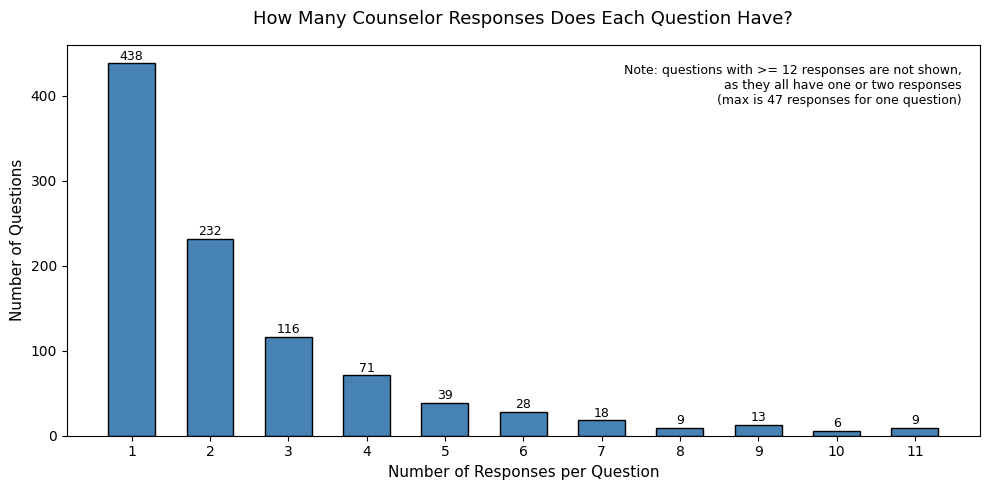

In [5]:
plot_data = response_dist[response_dist.index <= 11]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(plot_data.index, plot_data.values, color='steelblue', edgecolor='black', width=0.6)

ax.set_title('How Many Counselor Responses Does Each Question Have?', fontsize=13, pad=15)
ax.set_xlabel('Number of Responses per Question', fontsize=11)
ax.set_ylabel('Number of Questions', fontsize=11)
ax.set_xticks(plot_data.index)

# Add count label on top of each bar
for x, y in zip(plot_data.index, plot_data.values):
    ax.text(x, y + 1, str(y), ha='center', va='bottom', fontsize=9)

ax.annotate(
    'Note: questions with >= 12 responses are not shown,\n as they all have one or two responses\n(max is 47 responses for one question)',
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=9, color='black'
)

plt.tight_layout()
plt.savefig('../outputs/module4/responses_per_question.png', dpi=150, bbox_inches='tight')
plt.show()

### Word Count Analysis

In [6]:
# Word count = split by spaces and count
df_clean['context_words']  = df_clean['Context'].str.split().str.len()
df_clean['response_words'] = df_clean['Response'].str.split().str.len()

print("=" * 45)
print("  WORD COUNT ANALYSIS")
print("=" * 45)

print("\nUser question length (words):")
print(f"  Shortest  : {df_clean['context_words'].min()} words")
print(f"  Longest   : {df_clean['context_words'].max()} words")
print(f"  Average   : {df_clean['context_words'].mean():.0f} words")
print(f"  Median    : {df_clean['context_words'].median():.0f} words")

print(f"\nCounselor response length (words):")
print(f"  Shortest  : {df_clean['response_words'].min()} words")
print(f"  Longest   : {df_clean['response_words'].max()} words")
print(f"  Average   : {df_clean['response_words'].mean():.0f} words")
print(f"  Median    : {df_clean['response_words'].median():.0f} words")

  WORD COUNT ANALYSIS

User question length (words):
  Shortest  : 5 words
  Longest   : 526 words
  Average   : 57 words
  Median    : 47 words

Counselor response length (words):
  Shortest  : 0 words
  Longest   : 939 words
  Average   : 178 words
  Median    : 143 words


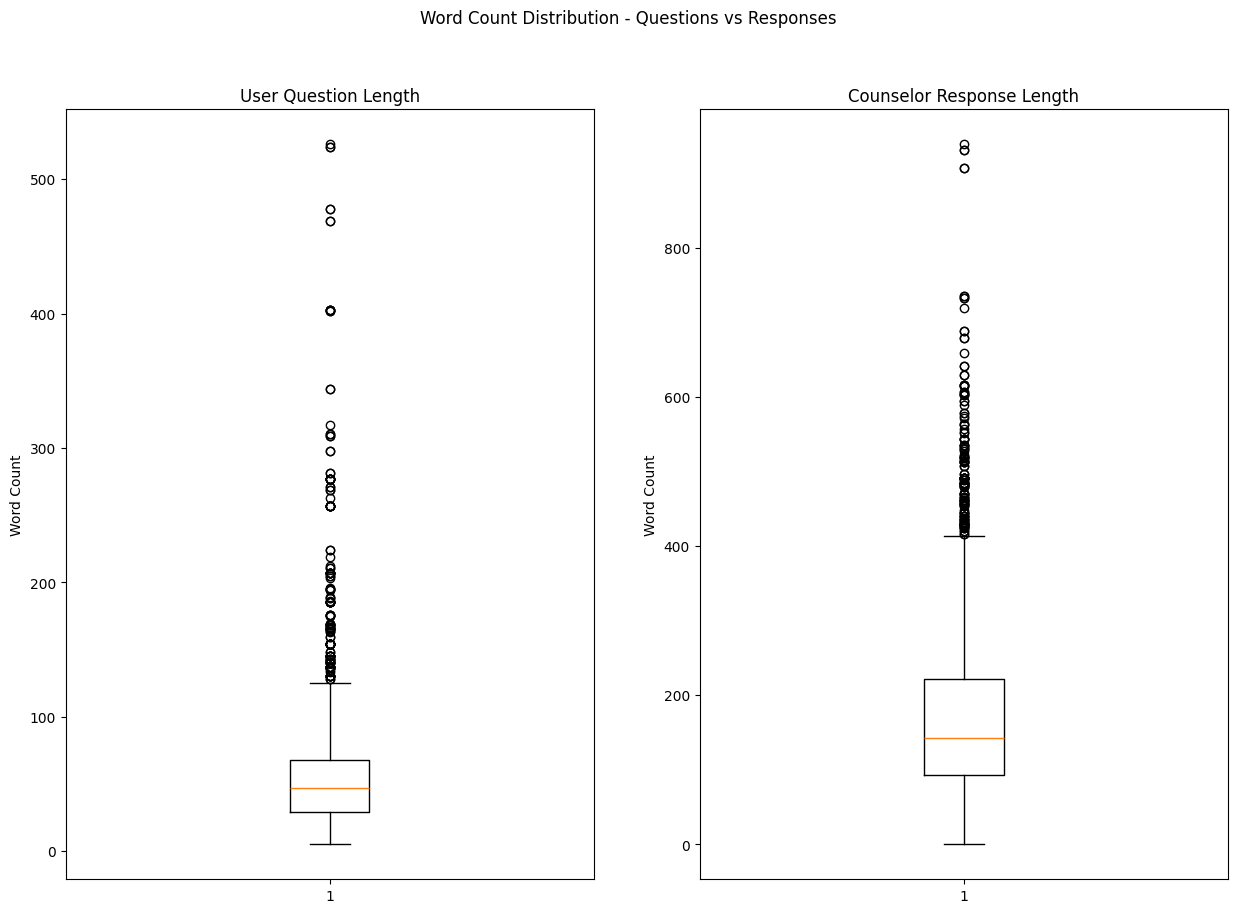

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

axes[0].boxplot(df_clean['context_words'])
axes[0].set_title('User Question Length')
axes[0].set_ylabel('Word Count')

axes[1].boxplot(df_clean['response_words'])
axes[1].set_title('Counselor Response Length')
axes[1].set_ylabel('Word Count')

fig.suptitle('Word Count Distribution - Questions vs Responses')
plt.show()

### Investigate Empty and Very Short Responses

In [8]:
# Find empty responses
empty_responses = df_clean[df_clean['response_words'] == 0]

print(f"Empty responses found: {len(empty_responses)}")
print("=" * 60)

for i, row in empty_responses.iterrows():
    all_responses_for_q = df_clean[df_clean['Context'] == row['Context']]
    n_total = len(all_responses_for_q)
    n_non_empty = (all_responses_for_q['response_words'] > 0).sum()

    print(f"Question:  {row['Context'][:300]}...")
    print(f"Total responses for this question : {n_total}")
    print(f"Non-empty responses               : {n_non_empty}")
    print("-" * 60)

Empty responses found: 4
Question:  From the moment I wake up, I hear what I think is my voice in my head. Even now, I hear it saying every word I’m thinking. When I lay down to sleep, I think of weird and crazy things, and the voice will never stop talking. I don’t know if it’s me thinking. It never stops. I’ll lay in my bed for hour...
Total responses for this question : 3
Non-empty responses               : 2
------------------------------------------------------------
Question:  I’m trying to make marriage work after a split. Before our split, he lied a lot and broke every promise to me. I don't think he cheated. Last month, I asked what women work with him, so he told me. Yesterday, I found out about a girl that he said he forgot about. Should I be upset?...
Total responses for this question : 11
Non-empty responses               : 10
------------------------------------------------------------
Question:  Every winter I find myself getting sad because of the weather.  How can I fi

In [9]:
# Very short but not empty
very_short = df_clean[(df_clean['response_words'] > 0) & (df_clean['response_words'] <= 20)].copy()

print(f"Very short responses (1-20 words): {len(very_short)}")
print("=" * 60)

for i, row in very_short.iterrows():
    all_responses_for_q = df_clean[df_clean['Context'] == row['Context']]
    n_total = len(all_responses_for_q)

    print(f"\nRow {i} | {row['response_words']} words | question has {n_total} total responses")
    print(f"Response: '{row['Response']}'")
    print(f"Question: {row['Context'][:150]}...")
    print("-" * 60)

Very short responses (1-20 words): 24

Row 131 | 14 words | question has 5 total responses
Response: 'Check this blog out:  Four-ways-add-self-esteem-friends-listHope you find a few nuggets of helpfulness in this.'
Question: I just don't know what I want in life anymore. I'm can't figure out what it is that is keeping me distracted and unfocused. I can't put things into pe...
------------------------------------------------------------

Row 385 | 1 words | question has 26 total responses
Response: 'Certainly.'
Question: I've gone to a couple therapy sessions so far and still everytime I walk in I get nervous and shaky. Is this normal? Should I still be feeling like th...
------------------------------------------------------------

Row 432 | 15 words | question has 6 total responses
Response: 'I can offer you hypnosis for confidence in presentations, via Skype, if you're in Cali.'
Question: I am a really shy person. I'm currently in a graduate program which requires lots of presentatio

#### Use this exact cell to search for a specific question and its responses, if you need to do further investigation

In [10]:
# type the question you want to search for here (or part of it)
search_query = "Sometimes 3 times a night"

# filter to get the rows where 'Context' contains the search query
specific_qa = df_clean[df_clean['Context'].str.contains(search_query, case=False, na=False)]


print(f"Found {len(specific_qa)} matching conversation(s)!\n")
print("=" * 80)

for index, row in specific_qa.iterrows():
    print("--> QUESTION:")
    print(row['Context'])
    print("-" * 80)
    print("--> ANSWER:")
    print(row['Response'])
    print("=" * 80)

Found 5 matching conversation(s)!

--> QUESTION:
Sometimes 3 times a night.
--------------------------------------------------------------------------------
--> ANSWER:
Perhaps more dreaming means that you are making use of your mind to solve problems.  I find that change states, while sometimes difficult, are very exciting.  They give you opportunity to grow more rapidly.  So I say: "congratulations!"  ~Mark (www.MarkMorrisLCSW.com and www.LivingYes.org)
--> QUESTION:
Sometimes 3 times a night.
--------------------------------------------------------------------------------
--> ANSWER:
Dreams are our chance to make sense of our waking lives.If you've got a lot going on in your life then your dreams are your assistants in understanding these happenings and dynamics.
--> QUESTION:
Sometimes 3 times a night.
--------------------------------------------------------------------------------
--> ANSWER:
As a depth therapist (aka "psychodynamic practitioner"), I do a lot of dream work with cl

#### Dropping Low Quality Responses

After inspection:
- 4 empty responses: other counselors answered the same question so it is safe to drop.
- 32 very short responses (under 20 words). When inspected, these are: spam,
  blog links, advertisements, or single words. not useful as counseling knowledge so drop them as well

We drop these rows only, not the questions themselves.
The questions still have other valid responses.

In [11]:
before = len(df_clean)

# Drop empty and very short responses
df_final = df_clean[df_clean['response_words'] >= 20].reset_index(drop=True)

after = len(df_final)

print(f"Rows before : {before}")
print(f"Rows dropped: {before - after}")
print(f"Rows after  : {after}")
print(f"\nNull check after dropping:")
print(f"  Empty contexts  : {df_final['Context'].isna().sum()}")
print(f"  Empty responses : {df_final['Response'].isna().sum()}")

Rows before : 2752
Rows dropped: 28
Rows after  : 2724

Null check after dropping:
  Empty contexts  : 0
  Empty responses : 0


### Question Length Investigation

In [12]:
df_unique = df_final.drop_duplicates(subset='Context').copy()

print(f"Unique questions after cleaning: {len(df_unique)}")
print()

# Define ranges
ranges = [
    ("Under 10 words", df_unique['context_words'] < 10),
    ("10-20 words", (df_unique['context_words'] >= 10) & (df_unique['context_words'] < 20)),]
#     ("20-30 words", (df_unique['context_words'] >= 20) & (df_unique['context_words'] < 30)),
#     ("30-80 words", (df_unique['context_words'] >= 30) & (df_unique['context_words'] < 80)),
#     ("80-150 words", (df_unique['context_words'] >= 80) & (df_unique['context_words'] < 150)),
#     ("150+ words", df_unique['context_words'] >= 150),
# ]

for label, mask in ranges:
    subset = df_unique[mask].sort_values('context_words')
    print(f"{label}: {len(subset)} questions")
    print("-" * 60)
    for _, row in subset.iterrows():
        print(f"[{int(row['context_words'])} words] {row['Context'].strip()}")
    print()

Unique questions after cleaning: 991

Under 10 words: 18 questions
------------------------------------------------------------
[5 words] Everything just makes me upset.
[5 words] Sometimes 3 times a night.
[6 words] I shake and have panic attacks.
[6 words] How do I stop those thoughts?
[6 words] What makes a healthy marriage last?
[6 words] People always judge others so rudely.
[7 words] Why am I attracted to older men?
[7 words] Nothing we've tried has worked so far.
[8 words] I can't understand what I pay attention to.
[8 words] After I told them, they yelled at me.
[8 words] I get very nervous and anxious/scared before sex.
[8 words] How does a person start the counseling process?
[9 words] How can I know if I'm just being paranoid?
[9 words] I have been having horrendous nightmares this whole month.
[9 words] We make love once per month. Is it normal?
[9 words] I feel like my time is going too fast
[9 words] What should I do when we see each other?
[9 words] Does counseling reall

### Questions With Only 1 Response

to check whether this response is useful or we can just drop the entire row


In [13]:
# Get questions with exactly 1 response after our cleaning
df_response_counts = df_final.groupby('Context')['Response'].count().reset_index()
df_response_counts.columns = ['Context', 'num_responses']

single_response_qs = df_response_counts[df_response_counts['num_responses'] == 1]['Context'].tolist()
single_df = df_final[df_final['Context'].isin(single_response_qs)].copy()
single_df['response_words'] = single_df['Response'].str.split().str.len()

print(f"Questions with exactly 1 response: {len(single_df)}")
print()
print("Response length breakdown for these questions:")
print(f"  Very short  (20-50 words)  : {((single_df['response_words'] >= 20) & (single_df['response_words'] < 30)).sum()}")


# Show the shortest ones so we can judge quality
print("Shortest responses in this group (top 10):")
print("-" * 60)
shortest = single_df.nsmallest(5, 'response_words')
for _, row in shortest.iterrows():
    print(f"\n[{row['response_words']} words]")
    print(f"Question : {row['Context'][:300].strip()}...")
    print(f"Response : {row['Response'].strip()}")
    print("-" * 60)

Questions with exactly 1 response: 441

Response length breakdown for these questions:
  Very short  (20-50 words)  : 3
Shortest responses in this group (top 10):
------------------------------------------------------------

[23 words]
Question : It has been going on more often lately, but not all the time. It has been starting to affect my driving, among other things....
Response : It's important to make an appointment with a neurologist and ophthalmologist ASAP for evaluation. There are medical conditions that can create this effect.
------------------------------------------------------------

[25 words]
Question : I am broke, but I am sure I have been depressed for the past couple of years. I have always had anxiety. I just need someone to talk to right now. I don't have any friends or family I can talk to. I'm on the verge of just giving up....
Response : Good question. There are resources out there - people to talk to. I'd try going to this link and calling the free 24/7 hotline:

### Investigate questions With Too Many Responses

One question has 47 responses. That's extreme. If we store all 47 as metadata, that's a massive payload per document. We need to filter them out.


In [14]:
df_response_counts = df_final.groupby('Context')['Response'].count().reset_index()
df_response_counts.columns = ['Context', 'num_responses']

heavy = df_response_counts[df_response_counts['num_responses'] > 20].sort_values(
    'num_responses', ascending=False
)

print(f"Questions with more than 20 responses: {len(heavy)}")
print()

for _, row in heavy.iterrows():
    print(f"[{row['num_responses']} responses]")
    print(f"  {row['Context'][:300].strip()}...")
    print()

Questions with more than 20 responses: 10

[47 responses]
  I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.
   I’ve never had counse...

[40 responses]
  How do you know you have the right therapist for you?
 How would I know how to "train" my therapist to be able to give me what I need from treatment?...

[37 responses]
  Is it normal for people to cry during therapy, or is it just me?...

[26 responses]
  Does counseling really do anything that can help people?...

[26 responses]
  How does a person start the counseling process?...

[25 responses]
  I've gone to a couple therapy sessions so far and still everytime I walk in I get nervous and shaky. Is this normal? Should I still be feeling like this?...

[25 responses]
  When my daughter is stressed about a si

###  Check Response Diversity in Those Top Questions

In [15]:
# Get the question with the most responses
top_question = df_response_counts.sort_values('num_responses', ascending=False).iloc[0]['Context']
top_responses = df_final[df_final['Context'] == top_question]['Response'].tolist()

n = len(top_responses)
print(f"Top question ({n} responses):")
print(f"  {top_question[:200].strip()}...")
print()
print(f"Response word counts: {[len(r.split()) for r in top_responses]}")
print()
print("First 3 responses to judge diversity:")
print("-" * 60)
for i, r in enumerate(top_responses[:3]):
    print(f"\n[Response {i+1} — {len(r.split())} words]")
    print(r[:300].strip())
    print("-" * 60)

Top question (47 responses):
  I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety...

Response word counts: [272, 139, 212, 42, 88, 248, 49, 68, 133, 28, 27, 54, 80, 109, 48, 179, 71, 48, 120, 209, 103, 84, 52, 74, 164, 194, 84, 91, 29, 211, 71, 67, 172, 120, 61, 61, 79, 150, 63, 106, 76, 271, 73, 287, 163, 142, 115]

First 3 responses to judge diversity:
------------------------------------------------------------

[Response 1 — 272 words]
Let me start by saying there are never too many concerns that you can bring into counselling. In fact, most people who come to see me for counselling have more than one issue they would like to work on in psychotherapy and most times these are all interconnected. In counselling, we work together, co
------------------------------------------------------------

[Response 2 — 139 words]
It is never too l

### Inspect Short Responses in High-Response Questions

In [16]:
for _, row in heavy.iterrows():
    question = row['Context']
    n = row['num_responses']
    responses = df_final[df_final['Context'] == question]['Response'].copy()
    short_ones = responses[responses.str.split().str.len() < 50]

    if len(short_ones) == 0:
        continue

    print(f"[{n} responses total — {len(short_ones)} under 50 words]")
    print(f"Question: {question[:300].strip()}...")
    print()
    for r in short_ones.values:
        wc = len(r.split())
        print(f"  ({wc} words) {r.strip()}")
        print()
    print("=" * 70)

[47 responses total — 7 under 50 words]
Question: I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.
   I’ve never had counse...

  (42 words) Absolutely not.  I strongly recommending working on one issue/need at a time.  In therapy you will set smart goals and objectives that will help you reach your goals.  I see you as a survivor and not a victim.  Best wishes to you.

  (49 words) Hi! Many people begin their therapeutic journey with histories just like yours and experience transformative shifts in their quality of life.  I hope you are able to find a counselor you feel comfortable working with and do the work if you feel called. Best of luck on your journey!

  (28 words) Just go! You start with the most prevalent issue by talking with your therapist. Healing o

#### Cleaning Decisions Summary

After deep investigation into question and response lengths, filtering by length 
alone turned out to be a bad idea. Short questions still got real, useful counselor responses. Same goes for short responses; anything above 20 words can carry genuine value.

What we actually dropped:
- 4 empty responses (their questions still had other valid responses)
- 32 responses under 20 words (spam, blog links, ads, single words)
- Exact duplicate rows (same question + same response text)

What we kept:
- All questions regardless of length
- All responses 20 words and above
- Questions with only 1 response — inspected and found solid

**Open issue:**

10 questions have 20+ responses each (max 47).
These are universal therapy questions that many counselors answered.
We will not cap them now. Once we reach the embedding phase, we will apply 
MMR (Maximum Marginal Relevance) to select the most diverse subset of responses 
per question before indexing into Qdrant, so the system is not overwhelmed with 
near-identical perspectives.

### Topic Analysis

We identify the main mental health themes covered in the dataset.
This tells us what the knowledge base is actually good at answering
and where it might struggle.

Method: keyword matching on unique questions.
Each question can belong to multiple topics.

In [17]:
# Work on unique questions only
unique_questions_list = df_final.drop_duplicates(subset='Context')['Context'].tolist()

# Define topics and their keywords
topics = {
    "Anxiety & Panic":      ["anxiety", "panic", "nervous", "worry", "fear", "scared", "shaky"],
    "Depression":           ["depress", "sad", "hopeless", "worthless", "empty", "numb", "cry"],
    "Relationships":        ["relationship", "boyfriend", "girlfriend", "husband", "wife",
                             "partner", "marriage", "divorce", "breakup", "dating"],
    "Trauma & Abuse":       ["trauma", "abuse", "assault", "rape", "molest", "ptsd",
                             "violent", "hurt", "victim"],
    "Family":               ["family", "parent", "mother", "father", "mom", "dad",
                             "sister", "brother", "child", "daughter", "son"],
    "Self Harm & Suicidal": ["suicide", "suicidal", "self harm", "cut myself",
                             "kill myself", "end my life", "don't want to live"],
    "Anger & Stress":       ["anger", "angry", "stress", "stressed", "mad",
                             "frustrated", "overwhelm", "snap"],
    "Sleep":                ["sleep", "insomnia", "nightmare", "awake", "tired", "exhausted"],
    "Self Esteem":          ["self esteem", "confidence", "worthless", "ugly",
                             "insecure", "ashamed", "embarrass"],
    "About Therapy":        ["counseling", "therapist", "therapy", "counselor",
                             "session", "treatment", "psychiatrist"],
    "Identity & Gender":    ["identity", "transgender", "gay", "bisexual", "lesbian",
                             "sexuality", "gender", "lgbtq"],
    "Addiction":            ["addiction", "addict", "alcohol", "drugs", "substance",
                             "drinking", "gambling"],
}

In [18]:
# Count matches per topic
topic_counts = {}
for topic, keywords in topics.items():
    count = sum(
        1 for q in unique_questions_list
        if any(kw in q.lower() for kw in keywords)
    )
    topic_counts[topic] = count

# Sort by frequency
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

print("Topic coverage across 991 unique questions:")
print("=" * 50)
for topic, count in topic_counts.items():
    pct = count / len(unique_questions_list) * 100
    print(f"  {topic:<25} {count:>4} questions ({pct:>5.1f}%)")

# Questions matching no topic
matched = set()
for q in unique_questions_list:
    for keywords in topics.values():
        if any(kw in q.lower() for kw in keywords):
            matched.add(q)
            break

unmatched = len(unique_questions_list) - len(matched)
print(f"\n  {'Uncategorized':<25} {unmatched:>4} questions ({unmatched/len(unique_questions_list)*100:>5.1f}%)")

Topic coverage across 991 unique questions:
  Family                     416 questions ( 42.0%)
  Relationships              396 questions ( 40.0%)
  Anger & Stress             200 questions ( 20.2%)
  Depression                 199 questions ( 20.1%)
  Anxiety & Panic            139 questions ( 14.0%)
  Trauma & Abuse             124 questions ( 12.5%)
  Sleep                       81 questions (  8.2%)
  About Therapy               76 questions (  7.7%)
  Addiction                   49 questions (  4.9%)
  Self Esteem                 47 questions (  4.7%)
  Self Harm & Suicidal        26 questions (  2.6%)
  Identity & Gender           25 questions (  2.5%)

  Uncategorized              140 questions ( 14.1%)


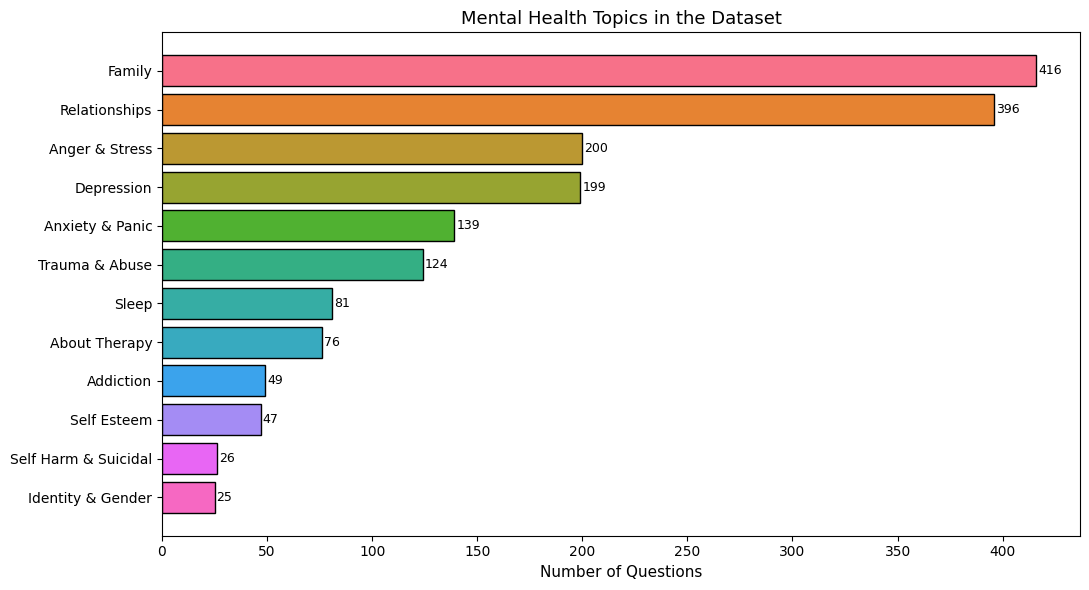

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

topics_list = list(topic_counts.keys())
counts_list = list(topic_counts.values())

colors = sns.color_palette("husl", len(topics_list))
ax.barh(topics_list[::-1], counts_list[::-1], color=colors[::-1], edgecolor='black')

ax.set_title('Mental Health Topics in the Dataset', fontsize=13)
ax.set_xlabel('Number of Questions', fontsize=11)

for i, count in enumerate(counts_list[::-1]):
    ax.text(count + 1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/module4/topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def count_topics(question):
    q = question.lower()
    return sum(1 for keywords in topics.values() if any(kw in q for kw in keywords))

topic_match_counts = [count_topics(q) for q in unique_questions_list]

print("How many topics does each question cover?")
print("=" * 45)

topic_dist = Counter(topic_match_counts)
for n, count in sorted(topic_dist.items()):
    pct = count / len(unique_questions_list) * 100
    print(f"  {n} topics: {count:>4} questions ({pct:.1f}%)")

print(f"\nAverage: {sum(topic_match_counts)/len(topic_match_counts):.2f} topics per question")

How many topics does each question cover?
  0 topics:  140 questions (14.1%)
  1 topics:  306 questions (30.9%)
  2 topics:  297 questions (30.0%)
  3 topics:  151 questions (15.2%)
  4 topics:   71 questions (7.2%)
  5 topics:   16 questions (1.6%)
  6 topics:    9 questions (0.9%)
  7 topics:    1 questions (0.1%)

Average: 1.79 topics per question


#### Topic Analysis

After reviewing the topic distribution, the dataset covers family and relationship
problems very well, around 40% each. Topics like career stress, eating disorders,
or identity are barely covered, so we should expect the model to perform better
on the dominant topics and struggle on the rare ones.

Note: percentages exceed 100% because one question can cover multiple topics.

The average question touches 1.79 topics, and very few questions go beyond 3.
This is a good sign as focused questions produce cleaner semantic signals for retrieval.

### Vocabulary Richness

In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

all_context_words  = []
all_response_words = []

for text in df_final['Context']:
    all_context_words.extend(clean_text(text))

for text in df_final['Response']:
    all_response_words.extend(clean_text(text))

context_vocab  = set(all_context_words)
response_vocab = set(all_response_words)

print("Vocabulary richness:")
print(f"  Total words in all questions : {len(all_context_words)}")
print(f"  Unique words in questions    : {len(context_vocab)}")
print(f"  Total words in all responses : {len(all_response_words)}")
print(f"  Unique words in responses    : {len(response_vocab)}")
print(f"  Combined unique vocabulary   : {len(context_vocab | response_vocab)}")

Vocabulary richness:
  Total words in all questions : 154771
  Unique words in questions    : 3684
  Total words in all responses : 487655
  Unique words in responses    : 15318
  Combined unique vocabulary   : 16042


In [22]:
clinical_terms = [
    "depression", "anxiety", "ptsd", "ocd", "bipolar", "schizophrenia",
    "adhd", "autism", "trauma", "dissociation", "borderline", "narcissist",
    "panic attack", "eating disorder", "anorexia", "bulimia", "insomnia",
    "suicidal", "self harm", "addiction"
]

print("Clinical term frequency in questions:")
print("-" * 40)
all_context_text = " ".join(df_final['Context'].tolist()).lower()

for term in clinical_terms:
    count = all_context_text.count(term)
    if count > 0:
        print(f"  {term:<20} {count} mentions")

Clinical term frequency in questions:
----------------------------------------
  depression           233 mentions
  anxiety              314 mentions
  ptsd                 15 mentions
  ocd                  2 mentions
  bipolar              23 mentions
  schizophrenia        11 mentions
  adhd                 6 mentions
  autism               12 mentions
  trauma               28 mentions
  borderline           5 mentions
  narcissist           8 mentions
  panic attack         24 mentions
  eating disorder      2 mentions
  insomnia             47 mentions
  suicidal             24 mentions
  self harm            1 mentions
  addiction            48 mentions


### Vocabulary Richness

This check was done to decide whether adding BM25 keyword search on top of
semantic search is worth it.

Users repeat the same conversational words constantly, only 3,684 unique words
across 154,771 total question words. The language is informal and repetitive.
Counselors on the other hand use much richer vocabulary, 15,318 unique words,
covering clinical terms and diverse explanations for the same problem.

This gap is actually why semantic search is the backbone here. To bridges the gap which pure keyword search would completely miss.

BM25 still adds value for specific clinical terms like "bipolar",
"insomnia", "panic attack", and "addiction" tho. These are specific issues that
a user typing them exactly deserves an exact match boost on top of semantic
similarity.

### Age and Gender Signals

In [23]:
age_patterns    = [r'\b\d{1,2}\s*year', r'\bage\s*\d', r'\bi am \d{2}', r'\bi\'m \d{2}']
gender_patterns = [r'\bwoman\b', r'\bman\b', r'\bfemale\b', r'\bmale\b',
                   r'\bgirl\b', r'\bboy\b', r'\bshe\b', r'\bhe\b',
                   r'\bher\b', r'\bhis\b', r'\bwife\b', r'\bhusband\b']

def has_pattern(text, patterns):
    text = text.lower()
    return any(re.search(p, text) for p in patterns)

df_unique = df_final.drop_duplicates(subset='Context').copy()

df_unique['has_age']    = df_unique['Context'].apply(lambda x: has_pattern(x, age_patterns))
df_unique['has_gender'] = df_unique['Context'].apply(lambda x: has_pattern(x, gender_patterns))

total = len(df_unique)

print(f"Checked on {total} unique questions only")
print()
print(f"Age signal    : {df_unique['has_age'].sum()} questions ({df_unique['has_age'].mean()*100:.1f}%)")
print(f"Gender signal : {df_unique['has_gender'].sum()} questions ({df_unique['has_gender'].mean()*100:.1f}%)")

Checked on 991 unique questions only

Age signal    : 85 questions (8.6%)
Gender signal : 544 questions (54.9%)


In [24]:
# you are free to change numbers here to show more or fewer examples
age_samples = df_unique[df_unique['has_age']]['Context'].head(5).tolist()

print("Sample questions with age signal:")
print("-" * 50)
for i, q in enumerate(age_samples):
    print(f"\n[{i+1}] {q[:200].strip()}...")

Sample questions with age signal:
--------------------------------------------------

[1] I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety...

[2] I am going through a divorce. He is extremely angry. He refuses to physically assist me with our teenager daughter. I have no extended family support. Often times, I feel overwhelmed, tired, and joyle...

[3] I'm currently struggling with diagnosed depression, anxiety, and Misophonia. Also, I am 99% sure I have Borderline Personality Disorder and Avoidant Personality Disorder. I read the DSM-IV, taken coll...

[4] I was married to a narcissist sociopath for 10 years. During that time I was a general manager. I used to help him financially and in other ways when we were together. But things began to change. He e...

[5] I've been married for 3 years and I have two kids. During my 3-years marri

In [25]:
# you are free to change numbers here to show more or fewer examples
gender_samples = df_unique[df_unique['has_gender']]['Context'].head(5).tolist()

print("Sample questions with gender signal:")
print("-" * 50)
for i, q in enumerate(gender_samples):
    print(f"\n[{i+1}] {q[:200].strip()}...")

Sample questions with gender signal:
--------------------------------------------------

[1] A few years ago I was making love to my wife when for no known reason I lost my erection,    Now I'm In my early 30s and my problem has become more and more frequent. This is causing major problems fo...

[2] I tried telling my husband I was depressed, and he ignored me. He said "you're always sad or depressed." And he picked up his phone and ignored me. I said, "Please don't exaggerate, that isn't true."...

[3] I am going through a divorce. He is extremely angry. He refuses to physically assist me with our teenager daughter. I have no extended family support. Often times, I feel overwhelmed, tired, and joyle...

[4] My girlfriend just quit drinking and she became really depressed. She told me that she wants to move. What can I do to help her? I want her to stay....

[5] I'm in my mid 20s with a husband and children. I love my family, but I feel like I've lost my identity, and I don't know who

#### Age and Gender Investigation

We checked whether age and gender signals could be extracted from questions
to enable personalized retrieval or filtering.

Age patterns matched only 8.6% of questions and on inspection most matches
were false positives, so age extraction was dropped.

Gender keywords appeared in 54.9% of questions but they mostly describe
people mentioned in the story, not the user themselves. Since the LLM
reads the full user message directly, it understands gender context without
any explicit extraction. 

No filtering or tagging needed or will be made.

# EDA Summary

Starting from 3,512 raw rows, we went through a full investigation before touching
any modeling or indexing.

What we cleaned:
- 234 exact duplicate rows (same question, same response text)
- 4 empty responses
- 32 responses under 20 words (spam, links, advertisements)
- Final dataset: 3,476 rows, 991 unique questions

What we found:
- Dataset is heavily focused on family and relationships (40-42%)
- Anxiety and depression are the most mentioned clinical topics
- 14% of questions are short or vague but still got solid counselor responses
  so filtering by length alone is a bad idea
- 10 questions have 20+ responses each, max is 47
  these will need MMR (Maximum Marginal Relevance) filtering before indexing
  to avoid overwhelming the system with near-identical perspectives
- User vocabulary is narrow and conversational (3,684 unique words)
  while counselor vocabulary is rich and clinical (15,318 unique words)
  this confirms semantic search is the backbone, with BM25 adding value
  only for specific clinical terms
- Age signals were too noisy to use (8.6%, mostly false positives)
- Gender signals exist in 54.9% of questions but describe people mentioned
  in the story, not the user, so the LLM handles this naturally from context

What is left open:
- MMR will be applied during the embedding phase to cap high-response questions
  by selecting the most semantically diverse subset of responses before indexing

The dataset is now well understood. We know what it covers, where it will
struggle, and what needs special handling. Ready to move to preprocessing and indexing.